# 00 - Get Highest Resolution Approximation of a Scene 

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import IPython
from IPython.display import Image, Video
import ipywidgets

import copy
import numpy as np
from glob import glob
import imageio.v3 as iio
import collections

import torch

import torch
from matplotlib.pylab import plt

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.cameras import MiniCam


from src.config import cfg, update_argparser, update_config


PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [2]:
DATA_ROOT = os.path.join(PROJECT_ROOT, 'data', '360_v2', 'kitchen')
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, 'output', 'tutorial')
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

DATA_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen
OUTPUT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/output/tutorial


In [ ]:
# python ./svraster/train.py \
#     --eval \
#     --source_path /home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen \
#     --model_path /home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03 \
#     --lambda_normal_dmean 0.001 --lambda_normal_dmed 0.001 \
#     --res_downscale 3.5 \
#     --n_iter 95000 \
#     --init_n_level 5 \
#     --adapt_every 4000 \
#     --adapt_from 4000 \
#     --prune_until 90000 \
#     --subdivide_until 90000 \
#     --checkpoint_iterations 999 1999 2999 3999 4999 5999 6999 7999 8999 9999 \
#                             10999 11999 12999 13999 14999 15999 16999 17999 18999 19999 \
#                             20999 21999 22999 23999 24999 25999 26999 27999 28999 29999 \
#                             30999 31999 32999 33999 34999 35999 36999 37999 38999 39999 \
#                             40999 41999 42999 43999 44999 45999 46999 47999 48999 49999 \
#                             50999 51999 52999 53999 54999 55999 56999 57999 58999 59999 \
#                             60999 61999 62999 63999 64999 65999 66999 67999 68999 69999 \
#                             70999 71999 72999 73999 74999 75999 76999 77999 78999 79999 \
#                             80999 81999 82999 83999 84999 85999 86999 87999 88999 89999 \
#                             90999 91999 92999 93999 94999 \
#     --sh_degree_init 0 \
#     --black_background \
#     --sh_degree 0


#                             # 90999 91999 92999 93999 94999 95999 96999 97999 98999 99999 \
#                             # 100999 101999 102999 103999 104999 105999 106999 107999 108999 109999 \
#                             # 110999 111999 112999 113999 114999 115999 116999 117999 118999 119999 \
#                             # 120999 121999 122999 123999 124999 125999 126999 127999 128999 129999 \

In [3]:
cfg.merge_from_file(cfg_filename="/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/config.yaml")

In [4]:
# Init and load data pack
data_pack = DataPack(
    source_path=cfg.data.source_path,
    image_dir_name=cfg.data.image_dir_name,
    mask_dir_name=cfg.data.mask_dir_name,
    res_downscale=cfg.data.res_downscale,
    res_width=cfg.data.res_width,
    skip_blend_alpha=cfg.data.skip_blend_alpha,
    alpha_is_white=cfg.model.white_background,
    data_device=cfg.data.data_device,
    use_test=cfg.data.eval,
    test_every=1,
)

# Instantiate data loader
test_cams = data_pack.get_test_cameras()


Read dataset in COLMAP format.
Read dataset in 11.149 seconds.


In [31]:
# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=False,
    black_background=True,
)
voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03", 95000)
voxel_model.freeze_vox_geo()

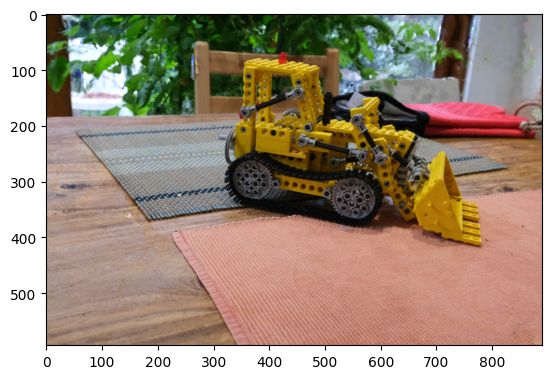

In [32]:
view = test_cams[0]
render_pkg = voxel_model.render(view, output_depth=False, output_normal=False, output_T=False)
img_true = torch.permute(view.image, dims=(1, 2, 0)).detach().cpu().numpy()
rendered_img = torch.permute(render_pkg['color'], dims=(1, 2, 0)).detach().cpu().numpy()
plt.imshow(rendered_img)

In [5]:
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=False,
    black_background=True,
)

list_num_vox = []
list_psnr = []
list_iters = range(1000, 96000, 1000)
list_imgs = []

for iter in list_iters:
    voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03", iter-1)
    voxel_model.freeze_vox_geo()

    list_mse = []
    for view in test_cams:
        render_pkg = voxel_model.render(view, output_depth=False, output_normal=False, output_T=False)
        rendered_img = im_tensor2np(render_pkg['color'].detach())    
        img_true = im_tensor2np(view.image)
        mse = np.square(img_true/255 - rendered_img/255).mean()
        list_mse.append(mse)

    psnr = -10 * np.log10(np.mean(list_mse))
    nvox = voxel_model.num_voxels
    list_psnr.append(psnr)
    list_num_vox.append(nvox)
    print(f"iter = {iter} nvox = {nvox} psnr = {psnr}")

iter = 1000 nvox = 53270 psnr = 19.17657453841769
iter = 2000 nvox = 53270 psnr = 19.538947405286635
iter = 3000 nvox = 53270 psnr = 19.67044976388609
iter = 4000 nvox = 53270 psnr = 19.71775177956784
iter = 5000 nvox = 71146 psnr = 20.87250894683836
iter = 6000 nvox = 71146 psnr = 21.017585820661154
iter = 7000 nvox = 71146 psnr = 21.069479882567435
iter = 8000 nvox = 71146 psnr = 21.111889774758986
iter = 9000 nvox = 81102 psnr = 22.131195706735262
iter = 10000 nvox = 81102 psnr = 22.23909303461422
iter = 11000 nvox = 81102 psnr = 21.914386942633858
iter = 12000 nvox = 81102 psnr = 21.9200682190772
iter = 13000 nvox = 67544 psnr = 22.441532558487953
iter = 14000 nvox = 67544 psnr = 22.448421331254554
iter = 15000 nvox = 67544 psnr = 22.497221164450693
iter = 16000 nvox = 67544 psnr = 22.49221768143289
iter = 17000 nvox = 84037 psnr = 22.680519062519142
iter = 18000 nvox = 84037 psnr = 22.72945210892217
iter = 19000 nvox = 84037 psnr = 22.690568456922797
iter = 20000 nvox = 84037 psnr

/tmp/ipykernel_229022/2755348801.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


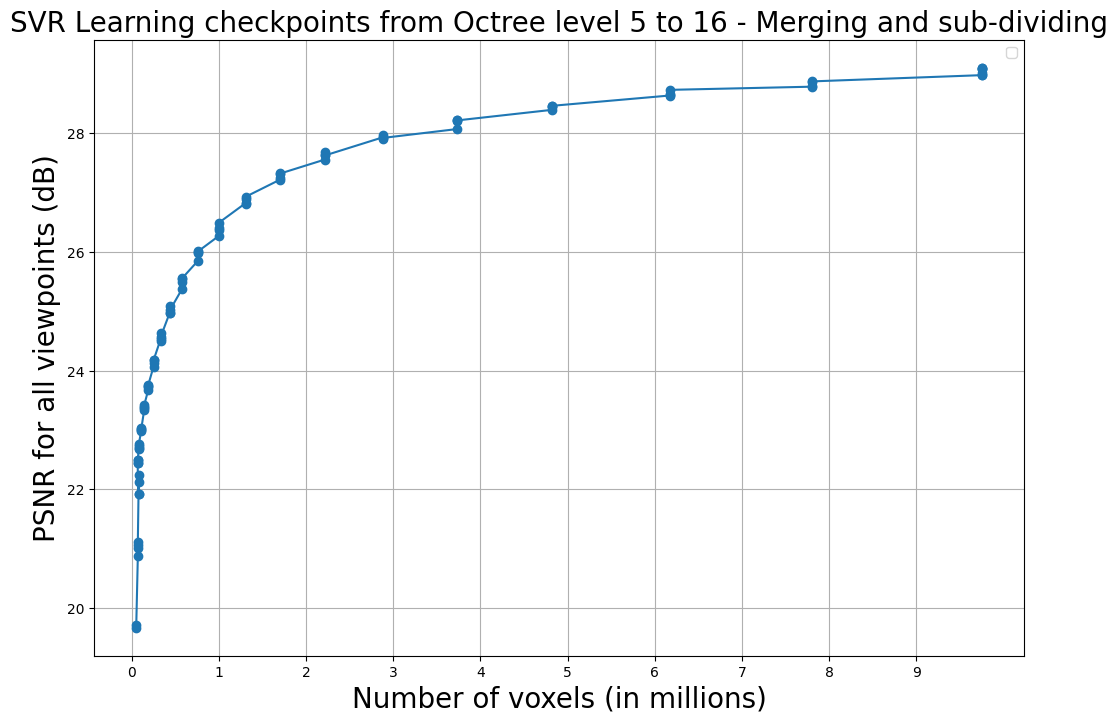

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(np.array(list_num_vox[2:])/1e6, list_psnr[2:], "o-")
ax.set_ylabel("PSNR for all viewpoints (dB)", fontsize=20)
ax.set_xlabel("Number of voxels (in millions)", fontsize=20) 
ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) 

plt.title("SVR Learning checkpoints from Octree level 5 to 16 - Merging and sub-dividing", fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

In [5]:
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=False,
    black_background=True,
)

list_num_vox = collections.OrderedDict()
list_psnr = collections.OrderedDict()
list_imgs = collections.OrderedDict()
list_iters = range(1000, 96000, 1000)

for iter in list_iters:
    voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03", iter-1)
    voxel_model.freeze_vox_geo()

    list_mse = []
    for view in test_cams:
        render_pkg = voxel_model.render(view, output_depth=False, output_normal=False, output_T=False)
        rendered_img = im_tensor2np(render_pkg['color'].detach())    
        img_true = im_tensor2np(view.image)
        mse = np.square(img_true/255 - rendered_img/255).mean()
        list_mse.append(mse)

    psnr = -10 * np.log10(np.mean(list_mse))
    nvox = voxel_model.num_voxels
    if (nvox in list_psnr) and list_psnr[nvox] <= psnr:
        list_psnr[nvox] = psnr
        list_num_vox[nvox] = iter
        list_imgs[nvox] = rendered_img
    elif (nvox not in list_psnr) :
        list_psnr[nvox] = psnr
        list_num_vox[nvox] = iter
        list_imgs[nvox] = rendered_img
    print(f"iter = {iter} nvox = {nvox} psnr = {psnr}")



iter = 1000 nvox = 53270 psnr = 19.17657453841769
iter = 2000 nvox = 53270 psnr = 19.538947405286635
iter = 3000 nvox = 53270 psnr = 19.67044976388609
iter = 4000 nvox = 53270 psnr = 19.71775177956784
iter = 5000 nvox = 71146 psnr = 20.87250894683836
iter = 6000 nvox = 71146 psnr = 21.017585820661154
iter = 7000 nvox = 71146 psnr = 21.069479882567435
iter = 8000 nvox = 71146 psnr = 21.111889774758986
iter = 9000 nvox = 81102 psnr = 22.131195706735262
iter = 10000 nvox = 81102 psnr = 22.23909303461422
iter = 11000 nvox = 81102 psnr = 21.914386942633858
iter = 12000 nvox = 81102 psnr = 21.9200682190772
iter = 13000 nvox = 67544 psnr = 22.441532558487953
iter = 14000 nvox = 67544 psnr = 22.448421331254554
iter = 15000 nvox = 67544 psnr = 22.497221164450693
iter = 16000 nvox = 67544 psnr = 22.49221768143289
iter = 17000 nvox = 84037 psnr = 22.680519062519142
iter = 18000 nvox = 84037 psnr = 22.72945210892217
iter = 19000 nvox = 84037 psnr = 22.690568456922797
iter = 20000 nvox = 84037 psnr

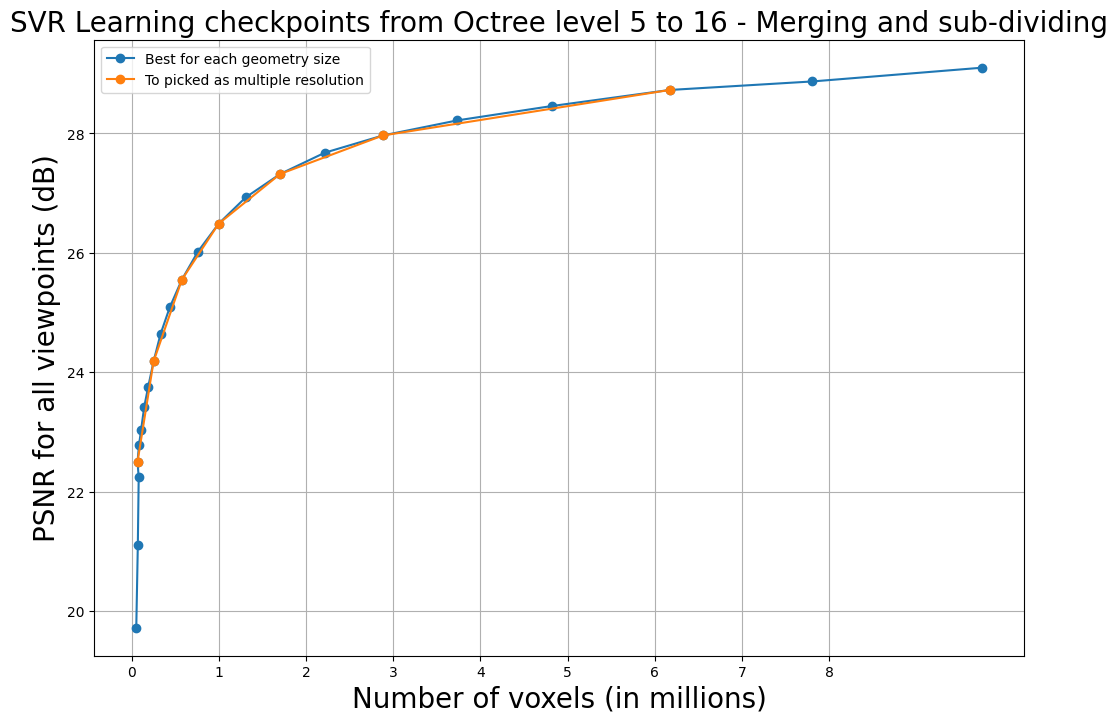

In [11]:
list_vox_best, list_psnr_best = np.array([k for k, v in list_psnr.items()]), np.array([v for k, v in list_psnr.items()])

size_picked = np.array([67544 , 251514, 576876, 998403, 1704689, 2881545, 6169629])
psnr_picked = np.array([list_psnr[s] for s in size_picked])

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(np.array(list_vox_best)/1e6, list_psnr_best, "o-", label="Best for each geometry size")
ax.plot(np.array(size_picked)/1e6, psnr_picked, "o-", label="To picked as multiple resolution")

ax.set_ylabel("PSNR for all viewpoints (dB)", fontsize=20)
ax.set_xlabel("Number of voxels (in millions)", fontsize=20)
ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8])

plt.title("SVR Learning checkpoints from Octree level 5 to 16 - Merging and sub-dividing", fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1288/208204343.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


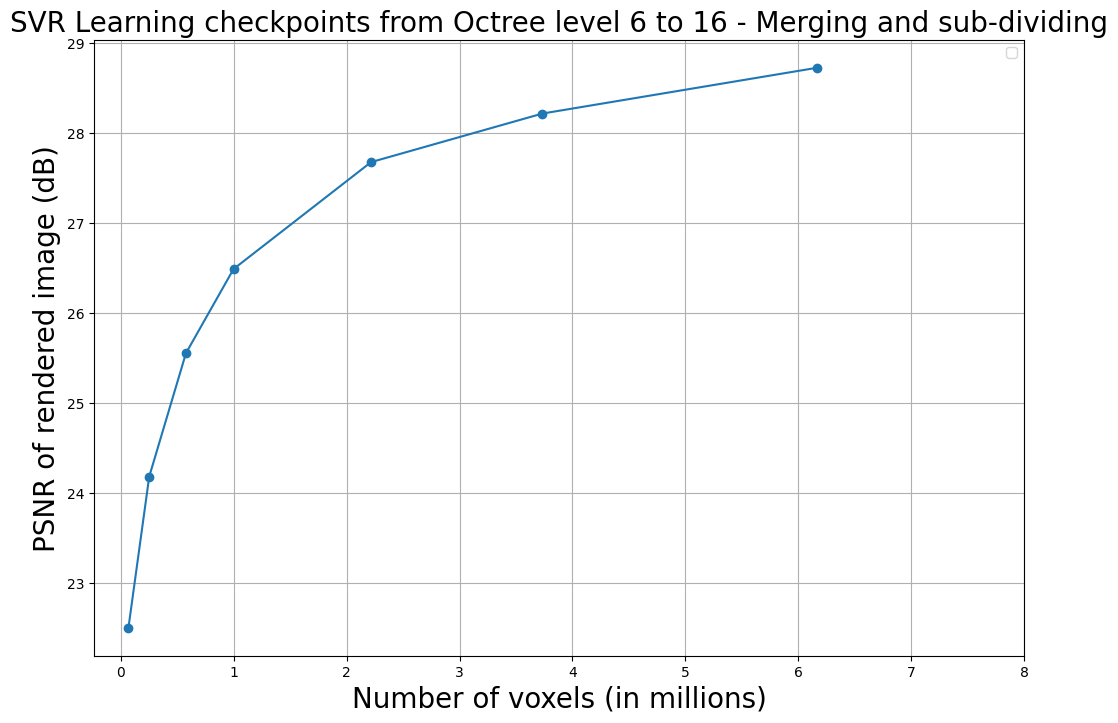

In [8]:
size = np.array([67544 , 251514, 576876, 998403, 2216360, 3735004, 6169629])
psnr = np.array([list_psnr[s] for s in size])

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(size/1e6, psnr, "o-")
ax.set_ylabel("PSNR of rendered image (dB)", fontsize=20)
ax.set_xlabel("Number of voxels (in millions)", fontsize=20)
ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8])

plt.title("SVR Learning checkpoints from Octree level 6 to 16 - Merging and sub-dividing", fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

In [15]:
list_vox_best, list_img_best = np.array([k for k, v in list_imgs.items()]), np.array([v for k, v in list_imgs.items()])
len(list_img_best)

16

In [9]:
# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=False,
    black_background=False,
)
voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v02", 64000)
voxel_model.freeze_vox_geo()

In [10]:
voxel_model.shs

tensor([[[0., 0., 0.]],

        [[0., 0., 0.]],

        [[0., 0., 0.]],

        ...,

        [[0., 0., 0.]],

        [[0., 0., 0.]],

        [[0., 0., 0.]]], device='cuda:0', requires_grad=True)

In [12]:
voxel_model.vox_center, voxel_model.vox_size

(tensor([[-3.4819,  0.6685,  5.3019],
         [-3.2546,  0.4412, 14.1674],
         [-3.2546,  1.3505, 14.1674],
         ...,
         [-3.7128,  2.9169,  0.4820],
         [-3.7128,  2.9240,  0.4749],
         [-3.7128,  2.9240,  0.4820]], device='cuda:0'),
 tensor([[0.4546],
         [0.9093],
         [0.9093],
         ...,
         [0.0071],
         [0.0071],
         [0.0071]], device='cuda:0'))